# Customer Segmentation Using K-Means Clustering

## K-Means

A mall wants to better understand their customers purchasing behavior in order to
increase sales. They have provided customer purchase data, including information such as
Age, Gender, Customer ID, Annual Income, Spending Score of origin from their customers.
By using the K-Means clustering method, to group their customers into several segments based on
their demographic and spending bahavior to allow the mall to understand their customers better and get an appropriate marketing strategies for each segment to enhance the mall's business.

### Step 1: Import the necessary libraries

To use k-means clustering in Python, we need to import the necessary libraries. We will be
using the NumPy, Pandas, Matplotlib, Seaborn, and Scikit-learn libraries.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

import warnings
warnings.filterwarnings('ignore')

### Step 2: Collect and pre-process the data

We will be using a `OnlineRetail.csv` dataset for this tutorial. Load this dataset from an
Excel file using Pandas.

In [2]:
dataset = pd.read_csv('Mall_Customers .csv')
dataset.head()

,CustomerID,Gender,Age Category,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,<20,19,15,39
1,2,Male,20-25,21,15,81
2,3,Female,20-25,20,16,6
3,4,Female,20-25,23,16,77
4,5,Female,25-35,31,17,40


In [49]:
dataset.shape

(200, 7)

This dataset consits of 200 data with 7 features.

In [4]:
dataset.isnull().sum()

CustomerID                0
Gender                    0
Age Category              0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

There is no missing value from the dataset given

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age Category            200 non-null    object
 3   Age                     200 non-null    int64 
 4   Annual Income (k$)      200 non-null    int64 
 5   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 9.5+ KB


From the code above, we can see that the dataset have 4 int(64) types and 2 objects which is `Gender` and `Age Category`

- Analyse the data

Before performing k-means for segmentation, we will try to conduct some data analysis to
determine the important information we can extract that can help us to draw the conclusion.

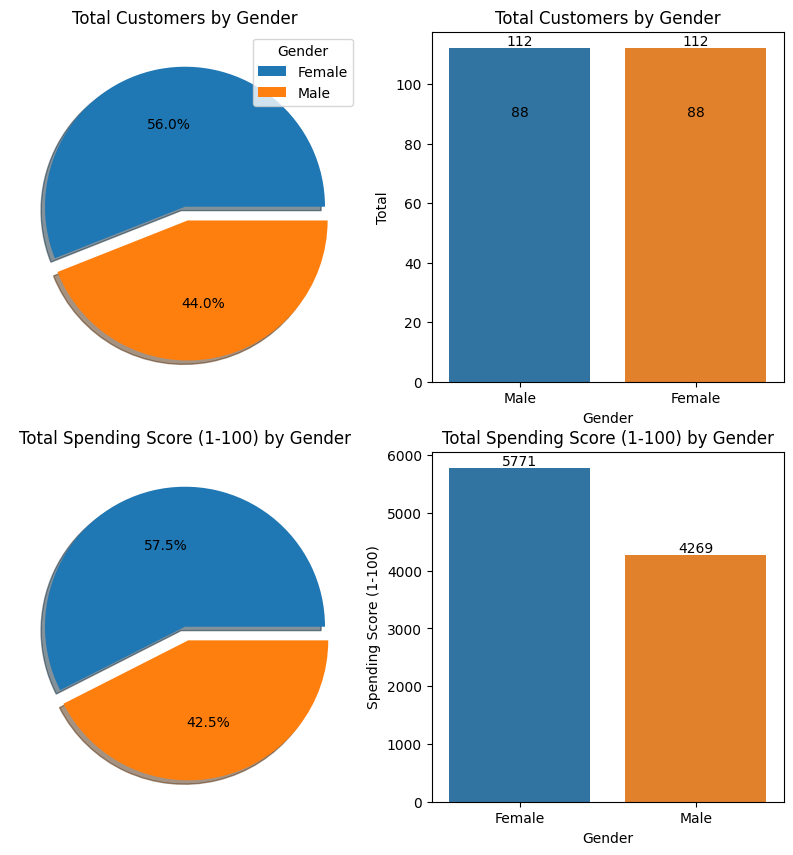

In [6]:
fig = plt.figure(figsize=(10, 10))

#Data Visualization 1
data1 = dataset['Gender'].value_counts()

explode = (0, 0.1)
ax1 = fig.add_subplot(2, 2, 1)
ax1.pie(data1.values, explode=explode, shadow=True, autopct='%1.1f%%')
ax1.set_title("Total Customers by Gender")
ax1.legend(data1.keys(), title ="Gender")

#Data visualization 2
ax2 = fig.add_subplot(2, 2, 2)
sns.barplot(x=data1.keys(), y=data1.values, ax=ax2) #or
sns.countplot(x=dataset['Gender'])
ax2.set_ylabel("Total")
ax2.set_title("Total Customers by Gender")
for i in ax2.containers:   # display data level
    ax2.bar_label(i,)

#Data visualization 3
gender = dataset.groupby('Gender', as_index=False, sort=False).agg({'Spending Score (1-100)': sum})
data2 = gender.sort_values(by='Spending Score (1-100)', ascending=False)
ax3 = fig.add_subplot(2, 2, 3)
ax3.pie(data2.values[:,1:2].reshape(-1,), explode=explode, shadow=True, autopct='%1.1f%%')
ax3.set_title("Total Spending Score (1-100) by Gender")

#Data Visualization 4
ax4 = fig.add_subplot(2, 2, 4)
sns.barplot(x='Gender', y='Spending Score (1-100)', data=data2, ax=ax4)
ax4.set_ylabel("Spending Score (1-100)")
ax4.set_title("Total Spending Score (1-100) by Gender")
for i in ax4.containers:
    ax4.bar_label(i,)

plt.show()

From the first analysis, the code visualized the total customer and total spending score (1-100) divided by gender. We can be seen that the number of female customers is 56.0%, more
than male customers who only give 44.0%. In terms of spending score, female customers also spent more than male customers that give 57.5% compared to 42.5%.

In the next analysis, we
will breakdown our data based on the customer’s age category.

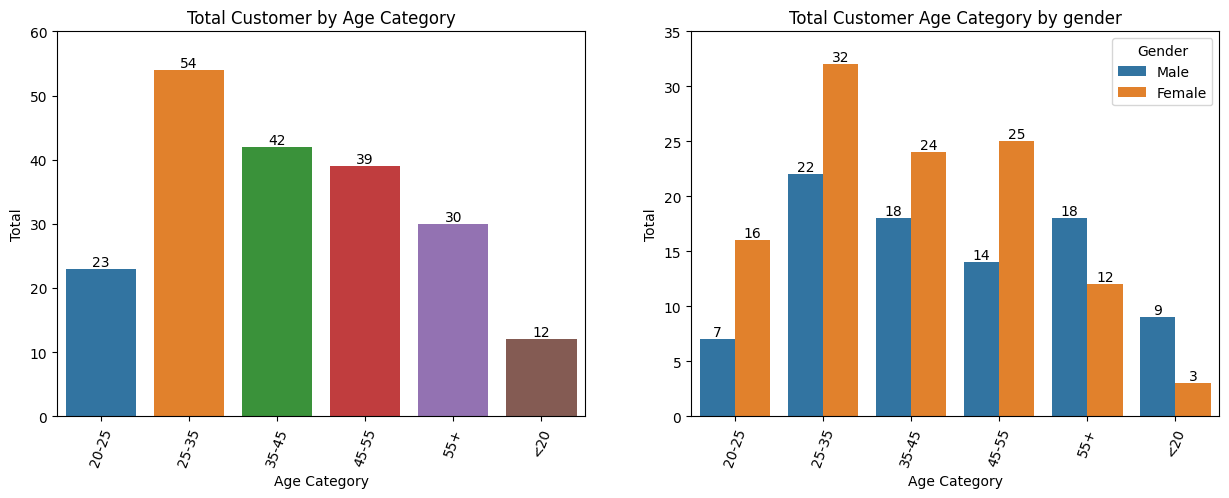

In [7]:
dataset = dataset.sort_values(by=['Age Category'], ascending=True)

fig = plt.figure(figsize=(15, 5))

#Data Visualization 5
ax1 = fig.add_subplot(1, 2, 1)
vis5 = sns.countplot(x='Age Category', data=dataset, ax=ax1)
ax1.set_ylabel("Total")
ax1.set_title("Total Customer by Age Category")
ax1.set_ylim(0, 60)
for item in vis5.get_xticklabels():
    item.set_rotation(70)
for i in vis5.containers:
    vis5.bar_label(i,)

#Data Visualization 6
ax2 = fig.add_subplot(1, 2, 2)
vis6 = sns.countplot(x='Age Category', hue='Gender', data=dataset, ax=ax2)
ax2.set_ylabel("Total")
ax2.set_title("Total Customer Age Category by gender")
ax2.set_ylim(0, 35)
for item in vis6.get_xticklabels():
    item.set_rotation(70)
for i in vis6.containers:
    vis6.bar_label(i,)

The first breakdown is the total number of customers from age category. This Mall has customers across various age category such as 20-25, 25-35, 35-45, 45-55, 55+ and <20. According to the outcome above, most customers are from age between 25-35 which 22 are males and 32 are females. Followed by the age category of 35-45.

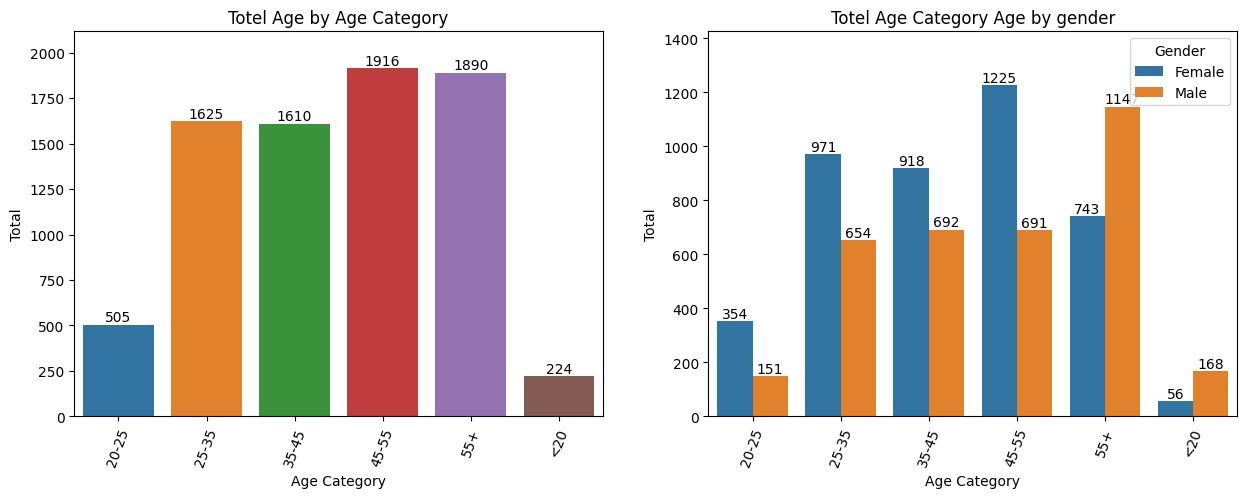

In [8]:
fig = plt.figure(figsize=(15, 5))

#Data Visualization 7
data7 = dataset.groupby(by=['Age Category'])['Age'].sum()
data7 = data7.reset_index()

ax1 = fig.add_subplot(1, 2, 1)
vis7 = sns.barplot(x='Age Category', y='Age', ci=None, data= data7, ax=ax1)
ax1.set_ylabel("Total")
ax1.set_title("Totel Age by Age Category")
ax1.set_ylim(0, max(data7['Age'])+200)
for item in vis7.get_xticklabels():
    item.set_rotation(70)
for i in vis7.containers:
    vis7.bar_label(i, fmt='%.0f')
    
# Data Visualization 8
data8 = dataset.groupby(by=['Age Category', 'Gender'])['Age'].sum()
data8 = data8.reset_index()

ax2 = fig.add_subplot(1, 2, 2)
vis8 = sns.barplot(x='Age Category', y='Age', hue='Gender', ci=None, data= data8, ax=ax2)
ax2.set_ylabel("Total")
ax2.set_title("Totel Age Category Age by gender")
ax2.set_ylim(0, max(data8['Age'])+200)
for item in vis8.get_xticklabels():
    item.set_rotation(70)
for i in vis8.containers:
    vis8.bar_label(i, fmt='%.0f')

The second breakdown is the total number of customers by age from age category. This Mall has customers across various age category such as 20-25, 25-35, 35-45, 45-55, 55+ and <20. According to the outcome above, most age are from age between 45-55 which 1225 are females and 691 are males. Followed by the age category of 55+.

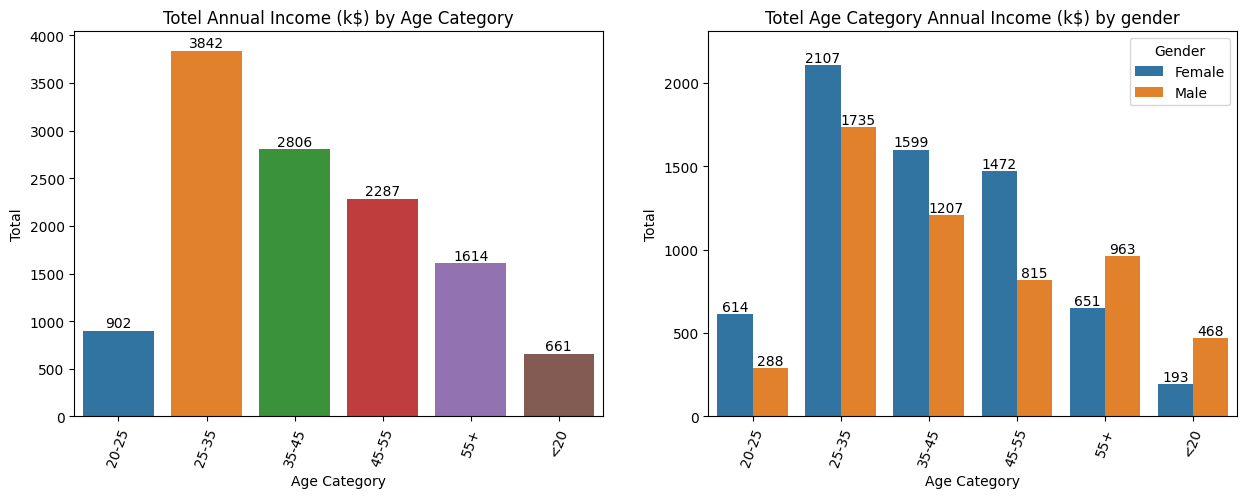

In [9]:
fig = plt.figure(figsize=(15, 5))

#Data Visualization 9
data9 = dataset.groupby(by=['Age Category'])['Annual Income (k$)'].sum()
data9 = data9.reset_index()

ax1 = fig.add_subplot(1, 2, 1)
vis9 = sns.barplot(x='Age Category', y='Annual Income (k$)', ci=None, data= data9, ax=ax1)
ax1.set_ylabel("Total")
ax1.set_title("Totel Annual Income (k$) by Age Category")
ax1.set_ylim(0, max(data9['Annual Income (k$)'])+200)
for item in vis9.get_xticklabels():
    item.set_rotation(70)
for i in vis9.containers:
    vis9.bar_label(i,)
    
# Data Visualization 10
data10 = dataset.groupby(by=['Age Category', 'Gender'])['Annual Income (k$)'].sum()
data10 = data10.reset_index()

ax2 = fig.add_subplot(1, 2, 2)
vis10 = sns.barplot(x='Age Category', y='Annual Income (k$)', hue='Gender', ci=None, data= data10, ax=ax2)
ax2.set_ylabel("Total")
ax2.set_title("Totel Age Category Annual Income (k$) by gender")
ax2.set_ylim(0, max(data10['Annual Income (k$)'])+200)
for item in vis10.get_xticklabels():
    item.set_rotation(70)
for i in vis10.containers:
    vis10.bar_label(i,)

The third breakdown is the total annual income (k$) from age category. This Mall has customers across various age category such as 20-25, 25-35, 35-45, 45-55, 55+ and <20. According to the outcome above, most annual income are from age between 25-35 which 2107 are males and 1735 are females. Followed by the age category of 35-45.

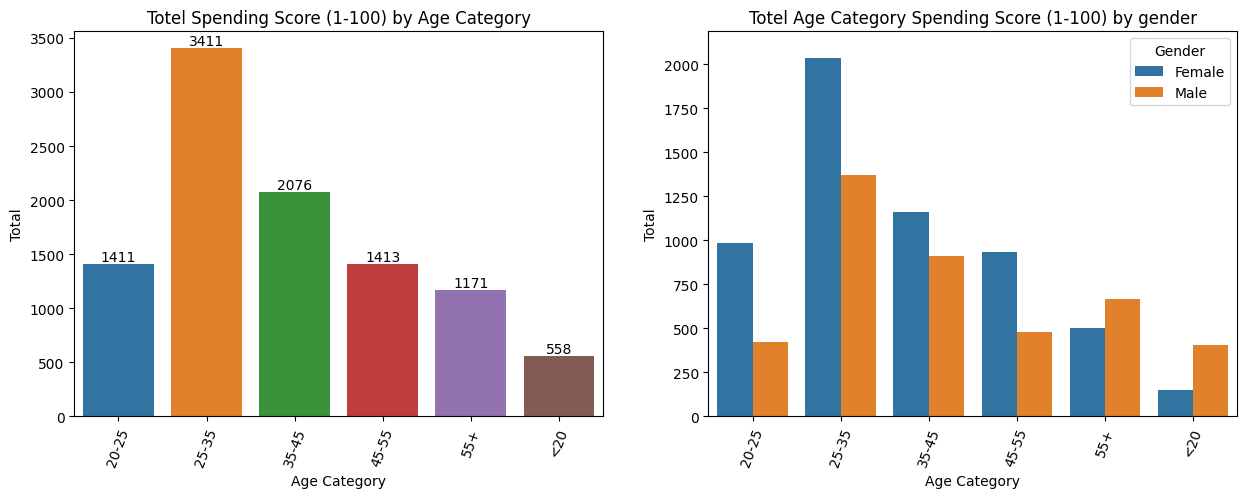

In [10]:
fig = plt.figure(figsize=(15, 5))

#Data Visualization 11
data11 = dataset.groupby(by=['Age Category'])['Spending Score (1-100)'].sum()
data11 = data11.reset_index()

ax1 = fig.add_subplot(1, 2, 1)
vis11 = sns.barplot(x='Age Category', y='Spending Score (1-100)', ci=None, data= data11, ax=ax1)
ax1.set_ylabel("Total")
ax1.set_title("Totel Spending Score (1-100) by Age Category")
ax1.set_ylim(0, max(data11['Spending Score (1-100)'])+150)
for item in vis11.get_xticklabels():
    item.set_rotation(70)
for i in vis11.containers:
    vis11.bar_label(i, fmt='%.0f')
    
# Data Visualization 12
data12 = dataset.groupby(by=['Age Category', 'Gender'])['Spending Score (1-100)'].sum()
data12 = data12.reset_index()

ax2 = fig.add_subplot(1, 2, 2)
vis12 = sns.barplot(x='Age Category', y='Spending Score (1-100)', hue='Gender', ci=None, data= data12, ax=ax2)
ax2.set_ylabel("Total")
ax2.set_title("Totel Age Category Spending Score (1-100) by gender")
ax2.set_ylim(0, max(data12['Spending Score (1-100)'])+150)
for item in vis12.get_xticklabels():
    item.set_rotation(70)


The fourth breakdown is the total spending score from age category. This Mall has customers across various age category such as 20-25, 25-35, 35-45, 45-55, 55+ and <20. According to the outcome above, most spending score are from age between 25-35. Followed by the age category of 35-45.

In [22]:
dataset_new = dataset
dataset_new = dataset_new.drop('Gender', axis=1)
dataset_new = dataset_new.drop('Age Category', axis=1)

dataset_new.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
99,100,20,61,49
78,79,23,54,52
84,85,21,54,57
87,88,22,57,55
95,96,24,60,52


To perform customer segmentation using k-means, we don’t need object features such
as ‘Gender’ and ‘Age category’, so we can drop them. We saved our data to be clustered into a
new dataset called ‘dataset_new’ so the original dataset is not lost, which will make it
easier to visualize the results later on.

- Data scaling

Before actually performing clustering, it’s better to scale the data first. Similar to other
machine learning methods, scaling the data is intended to ensure that all variables within
the data used for clustering have the same or at least a similar value range. This is important

because if the variables within the data have different scales, then the distance between data
points in the feature space will be more influenced by the variables that have larger scale
and the results are more likely inaccurate or even completely wrong. Therefore, scaling
data becomes a very important step before performing clustering. The following code
shows how to perform data scaling in our new dataset.

In [23]:
#Data Scaling
from sklearn.preprocessing import StandardScaler

datascaler = StandardScaler().fit(dataset_new)
data_scaled = datascaler.transform(dataset_new)

data_scaled = pd.DataFrame(data_scaled, columns=['CustomerID', 'Age','Annual Income (k$)', 'Spending Score (1-100)'])
data_scaled.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,-0.008660,-1.352802,0.016795,-0.046586
1,-0.372396,-1.137502,-0.250391,0.069879
2,-0.268471,-1.281035,-0.250391,0.263987
3,-0.216509,-1.209269,-0.135883,0.186343
4,-0.077943,-1.065735,-0.021375,0.069879


### Step 4: Build and train the model

Before building the k-means model, firstly we have to choose the value of k. One
technique to determine the value is by using the elbow rule. The goal of the elbow rule is
to determine the number of clusters that produces the most significant decrease in inertia.
Inertia is a measure of the average distance between points in the same cluster. The elbow
rule will show a graph of the decreasing inertia that becomes slower as the number of
clusters is increased. At a certain point, the decrease in inertia is no longer significant or
"bent" (resembling an elbow), hence it is called the elbow point. The optimal number of
clusters is the number of clusters before the elbow point is reached.

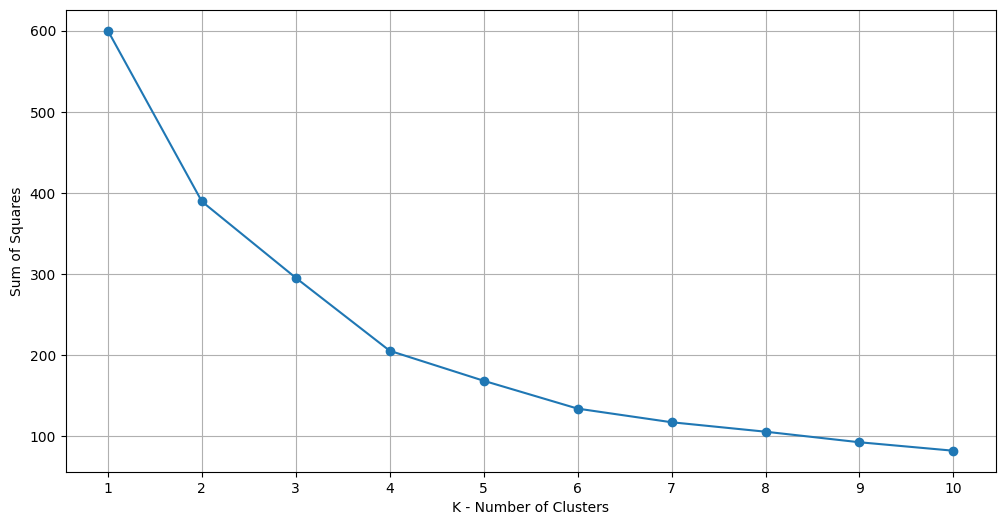

In [24]:
from sklearn.cluster import KMeans
from sklearn import cluster

sse = []

krange = list(range(1,11))
X = data_scaled[['Age','Annual Income (k$)', 'Spending Score (1-100)']].values

for n in krange:
    model = cluster.KMeans(n_clusters=n, random_state=3)
    model.fit_predict(X)
    cluster_assignments = model.labels_
    centers = model.cluster_centers_
    sse.append(np.sum((X - centers[cluster_assignments]) ** 2))

# Plot the results.
fig = plt.figure(figsize = (12,6))
plt.plot(krange, sse, marker='o')
plt.xlabel("K - Number of Clusters")
plt.xticks(np.arange(1,11,1))
plt.ylabel("Sum of Squares")
plt.grid(True)
plt.show()

From the figure above, the possible elbow point occurs when k is 4 or 5, because at these
two points, the decrease of inertia is no longer significant. However, in this we
will choose k = 5. 


By using k = 5, we will determine customer segmentation based on three features, which
are 'Age', 'Annual income', and 'Spending Score'. The results segmentation results between
these features are shown below.

In [27]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=5)
km.fit(data_scaled[['Annual Income (k$)', 'Spending Score (1-100)']])
y = km.predict(data_scaled[['Annual Income (k$)', 'Spending Score (1-100)']])
dataset['Cluster'] = y
dataset.head()

,CustomerID,Gender,Age Category,Age,Annual Income (k$),Spending Score (1-100),Cluster
99,100,Male,20-25,20,61,49,2
78,79,Female,20-25,23,54,52,2
84,85,Female,20-25,21,54,57,2
87,88,Female,20-25,22,57,55,2
95,96,Male,20-25,24,60,52,2


From the above table, can be seen the clustering result that has been done. For instance,
the customer with ID 100 has been segmented into cluster 2, then customer with ID
79 is in cluster 2, and so on. Then we can see the segmentation of this cluster
distribution in a plot with the following code.

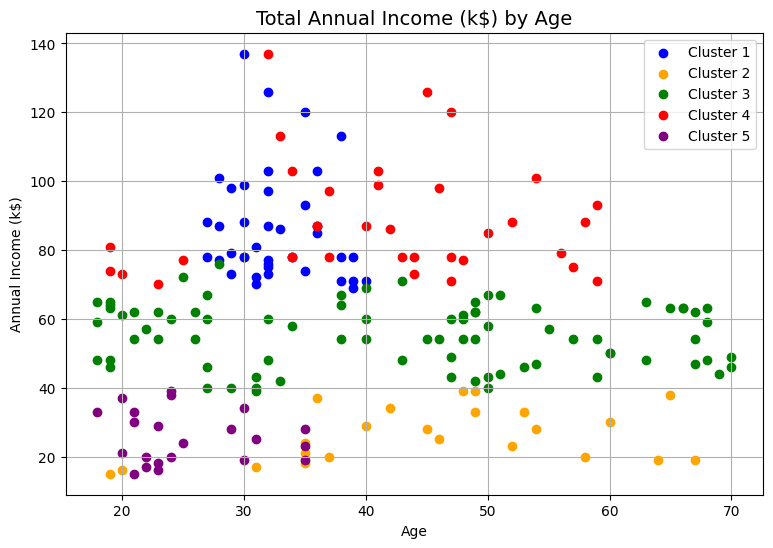

In [28]:
fig = plt.figure(figsize = (9,6))
plt.scatter(
    dataset.loc[dataset['Cluster'] == 0]['Age'],
    dataset.loc[dataset['Cluster'] == 0]['Annual Income (k$)'],
    c='blue', label='Cluster 1')

plt.scatter(
    dataset.loc[dataset['Cluster'] == 1]['Age'],
    dataset.loc[dataset['Cluster'] == 1]['Annual Income (k$)'],
    c='orange', label='Cluster 2')

plt.scatter(
    dataset.loc[dataset['Cluster'] == 2]['Age'],
    dataset.loc[dataset['Cluster'] == 2]['Annual Income (k$)'],
    c='green', label='Cluster 3')

plt.scatter(
    dataset.loc[dataset['Cluster'] == 3]['Age'],
    dataset.loc[dataset['Cluster'] == 3]['Annual Income (k$)'],
    c='red', label='Cluster 4')

plt.scatter(
    dataset.loc[dataset['Cluster'] == 4]['Age'],
    dataset.loc[dataset['Cluster'] == 4]['Annual Income (k$)'],
    c='purple', label='Cluster 5')

plt.title('Total Annual Income (k$) by Age', size=14)
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.legend()
plt.grid()
plt.show()

The figure above shows customer segmentation based on age and annual income. Every point
represents one customer. It should be noted that k-means divides the cluster randomly, so
we have to determine the value of each cluster ourselves. For instance, in the figure above shows that
cluster 5 is the cluster that gives the minimum impact on our income because it can be seen
that the purple dots represent customers who give low age and also low annual income. On
the other hand, cluster 4 is the cluster that represents customers with high value because
these customers provide high age and high annual income. The same thing can be observed
from customer segmentation based on age and spending score on Figure below.

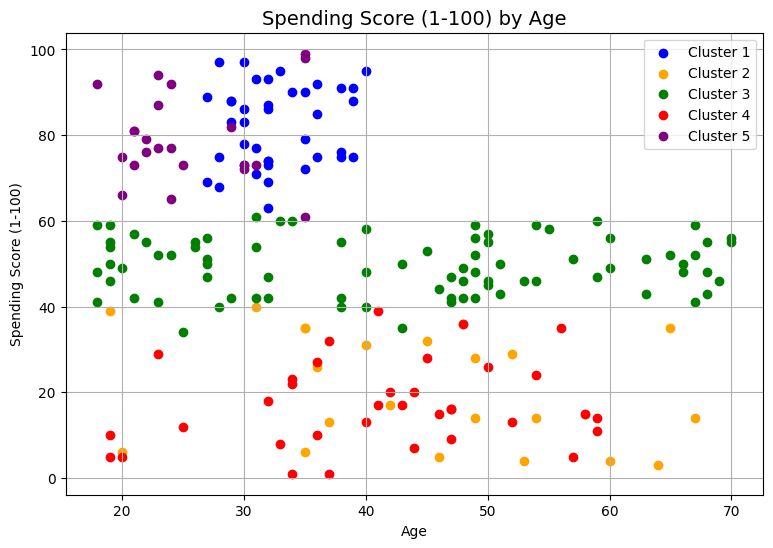

In [30]:
fig = plt.figure(figsize = (9,6))
plt.scatter(
    dataset.loc[dataset['Cluster'] == 0]['Age'],
    dataset.loc[dataset['Cluster'] == 0]['Spending Score (1-100)'],
    c='blue', label='Cluster 1')

plt.scatter(
    dataset.loc[dataset['Cluster'] == 1]['Age'],
    dataset.loc[dataset['Cluster'] == 1]['Spending Score (1-100)'],
    c='orange', label='Cluster 2')

plt.scatter(
    dataset.loc[dataset['Cluster'] == 2]['Age'],
    dataset.loc[dataset['Cluster'] == 2]['Spending Score (1-100)'],
    c='green', label='Cluster 3')

plt.scatter(
    dataset.loc[dataset['Cluster'] == 3]['Age'],
    dataset.loc[dataset['Cluster'] == 3]['Spending Score (1-100)'],
    c='red', label='Cluster 4')

plt.scatter(
    dataset.loc[dataset['Cluster'] == 4]['Age'],
    dataset.loc[dataset['Cluster'] == 4]['Spending Score (1-100)'],
    c='purple', label='Cluster 5')

plt.title('Spending Score (1-100) by Age', size=14)
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid()
plt.show()

In Figure above, can be observed that clusters 1 and 3 represent customers with high value
because these clusters give high age (cluster 3) or give high spending score(cluster
1). This means that these customers either from high age or make few spendings, but when
they do purchase, they provide a significant amount of sales. On the other hand, cluster 4
represents customers with low value because they not only have infrequent spendings but also
give from low age.

If we combine these three features, the result can be seen in the
following 3d plot.

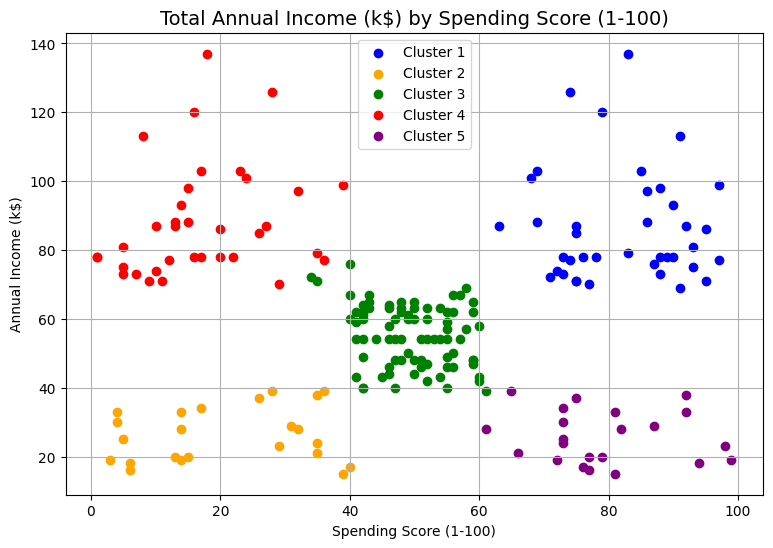

In [31]:
fig = plt.figure(figsize = (9,6))
plt.scatter(
    dataset.loc[dataset['Cluster'] == 0]['Spending Score (1-100)'],
    dataset.loc[dataset['Cluster'] == 0]['Annual Income (k$)'],
    c='blue', label='Cluster 1')

plt.scatter(
    dataset.loc[dataset['Cluster'] == 1]['Spending Score (1-100)'],
    dataset.loc[dataset['Cluster'] == 1]['Annual Income (k$)'],
    c='orange', label='Cluster 2')

plt.scatter(
    dataset.loc[dataset['Cluster'] == 2]['Spending Score (1-100)'],
    dataset.loc[dataset['Cluster'] == 2]['Annual Income (k$)'],
    c='green', label='Cluster 3')

plt.scatter(
    dataset.loc[dataset['Cluster'] == 3]['Spending Score (1-100)'],
    dataset.loc[dataset['Cluster'] == 3]['Annual Income (k$)'],
    c='red', label='Cluster 4')

plt.scatter(
    dataset.loc[dataset['Cluster'] == 4]['Spending Score (1-100)'],
    dataset.loc[dataset['Cluster'] == 4]['Annual Income (k$)'],
    c='purple', label='Cluster 5')

plt.title('Total Annual Income (k$) by Spending Score (1-100)', size=14)
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Annual Income (k$)')
plt.legend()
plt.grid()
plt.show()

From the customer segmentation result above, we can see that,
- Cluster 1 (Blue): represents earning high and also spending high which can said that there are the target customers.
- Cluster 2 (Yellow): representse earning less and spending less
- Cluster 3 (Green): represents avarage in terms of earning and spending
- Cluster 4 (Red): represents earning more but spending less
- Cluster 5 (Purple): represents earning less but spending more

The next step is to analyze the characteristics and preferences of each segment, such as their average age,
income, spending score, and gender distribution.

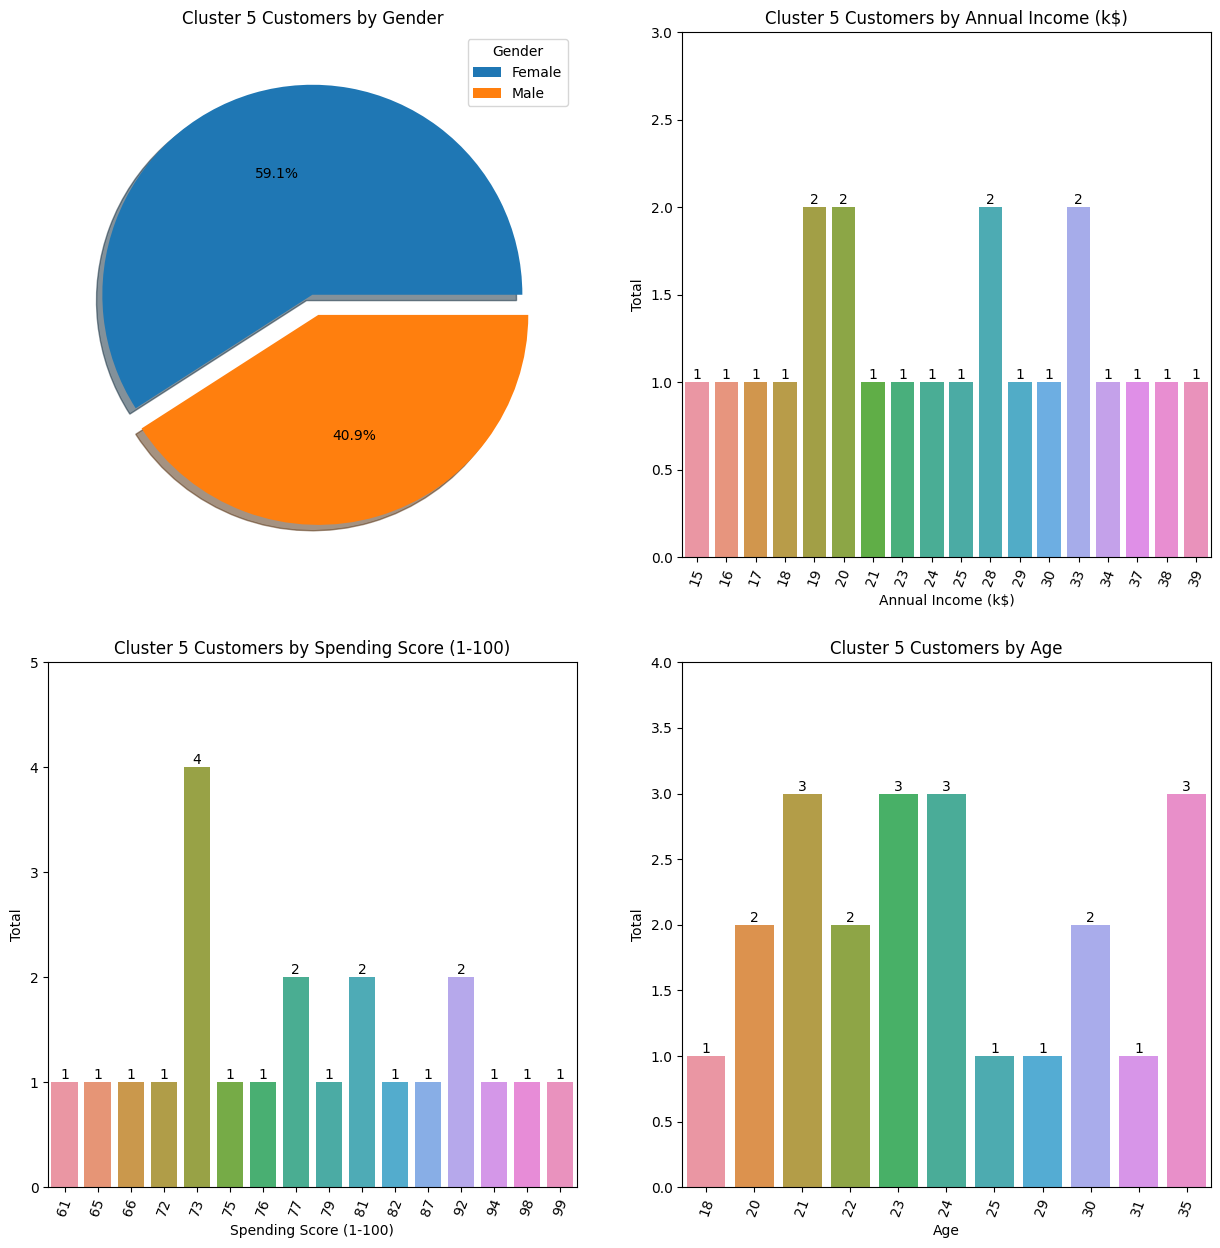

In [38]:
#Based on cluster 5
cluster_5 = dataset.loc[dataset['Cluster'] == 4]
gender_cluster_5 = cluster_5['Gender'].value_counts()

fig = plt.figure(figsize=(15, 15))

#Data Visualization 13
explode = (0, 0.1)
ax1 = fig.add_subplot(2, 2, 1)
ax1.pie(gender_cluster_5, explode=explode, shadow=True, autopct='%1.1f%%')
ax1.set_title("Cluster 5 Customers by Gender")
ax1.legend(gender_cluster_5.keys(), title ="Gender")

#Data Visualization 14
ax2 = fig.add_subplot(2, 2, 2)
vis14 = sns.countplot(x='Annual Income (k$)', data=cluster_5, ax=ax2)
ax2.set_ylabel("Total")
ax2.set_title("Cluster 5 Customers by Annual Income (k$)")
ax2.set_ylim(0, 3)
for item in vis14.get_xticklabels():
    item.set_rotation(70)
for i in vis14.containers:
    vis14.bar_label(i, fmt='%.0f')

#Data Visualization 15
ax2 = fig.add_subplot(2, 2, 3)
vis15 = sns.countplot(x='Spending Score (1-100)', data=cluster_5, ax=ax2)
ax2.set_ylabel("Total")
ax2.set_title("Cluster 5 Customers by Spending Score (1-100)")
ax2.set_ylim(0, 5)
for item in vis15.get_xticklabels():
    item.set_rotation(70)
for i in vis15.containers:
    vis15.bar_label(i, fmt='%.0f')

#Data Visualization 16
ax2 = fig.add_subplot(2, 2, 4)
vis16 = sns.countplot(x='Age', data=cluster_5, ax=ax2)
ax2.set_ylabel("Total")
ax2.set_title("Cluster 5 Customers by Age")
ax2.set_ylim(0, 4)
for item in vis16.get_xticklabels():
    item.set_rotation(70)
for i in vis16.containers:
    vis16.bar_label(i, fmt='%.0f')


The figure above is shows that **cluster 5** which is **less income and high spending** compared to other cluster. Cluster 5 contains customers with 40.9% are males and 59.1% are females. Also, we can see that most customers are come from age 21 to 35 age old. Therefore, the target market strategies for this segment, the mall can offer frequent discounts, coupons, or special deals on selected products or services to provide affordable options to price-sensitive customers. Next, Utilize targeted email campaigns, tailored product suggestions, or personalized offers based on past purchases or browsing history. Also, the mall can consider implementing loyalty-based financing programs where customers with a consistent purchase history can access extended credit or more favorable terms.

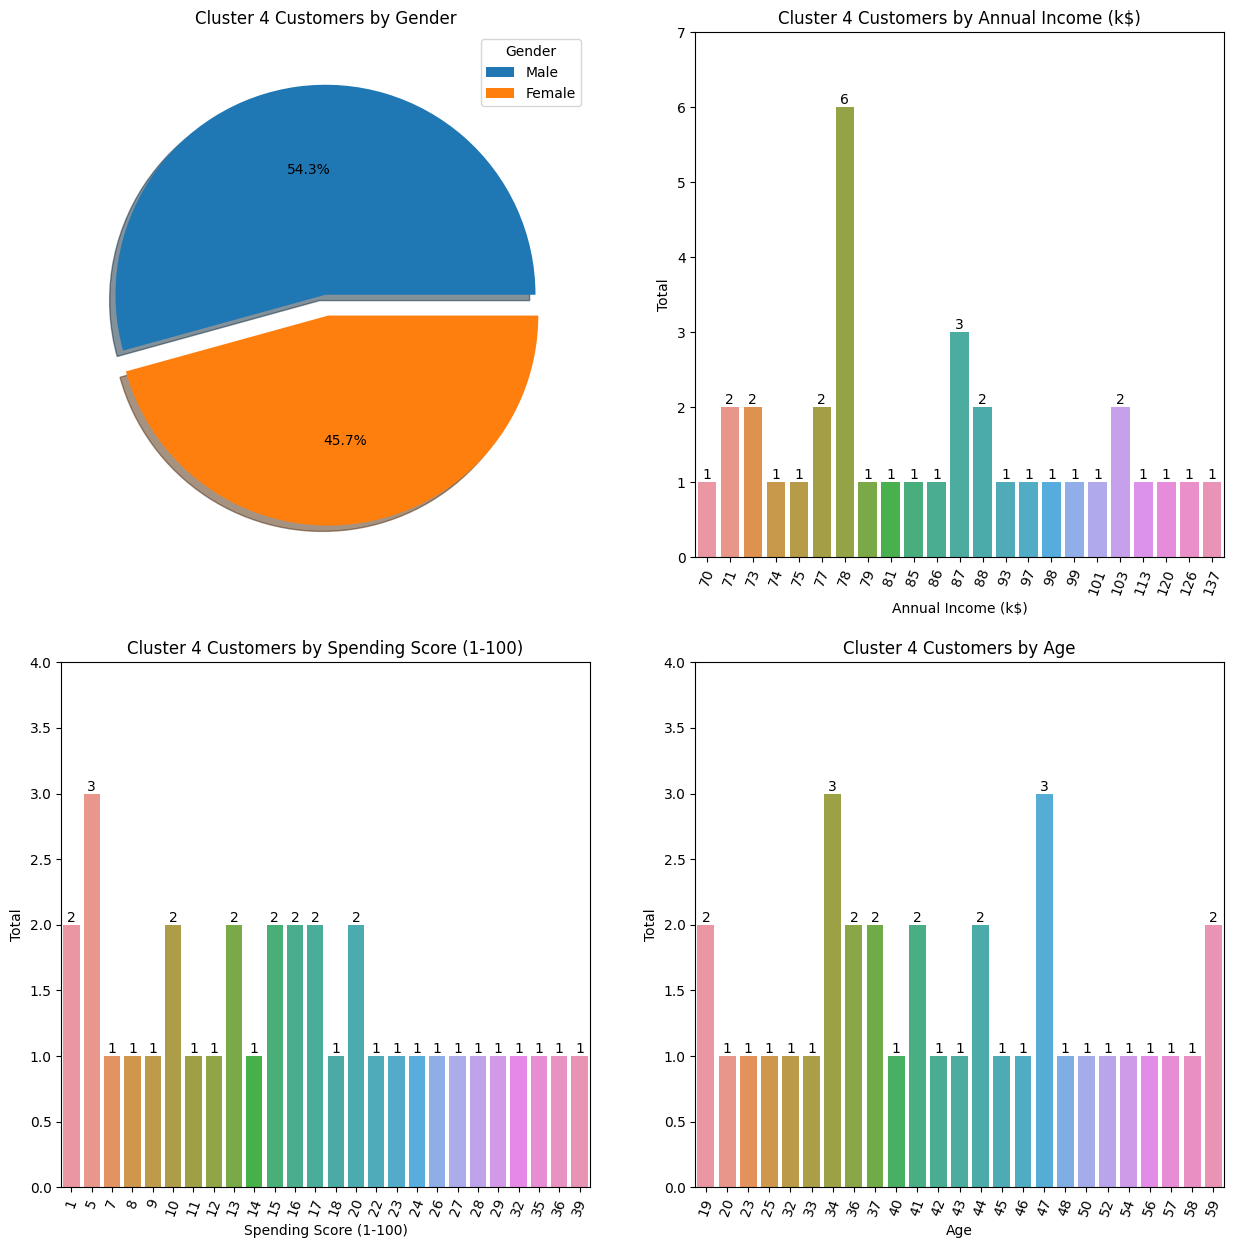

In [40]:
#Based on cluster 4
cluster_4 = dataset.loc[dataset['Cluster'] == 3]
gender_cluster_4 = cluster_4['Gender'].value_counts()

fig = plt.figure(figsize=(15, 15))

#Data Visualization 17
explode = (0, 0.1)
ax1 = fig.add_subplot(2, 2, 1)
ax1.pie(gender_cluster_4, explode=explode, shadow=True, autopct='%1.1f%%')
ax1.set_title("Cluster 4 Customers by Gender")
ax1.legend(gender_cluster_4.keys(), title ="Gender")

#Data Visualization 18
ax2 = fig.add_subplot(2, 2, 2)
vis18 = sns.countplot(x='Annual Income (k$)', data=cluster_4, ax=ax2)
ax2.set_ylabel("Total")
ax2.set_title("Cluster 4 Customers by Annual Income (k$)")
ax2.set_ylim(0, 7)
for item in vis18.get_xticklabels():
    item.set_rotation(70)
for i in vis18.containers:
    vis18.bar_label(i, fmt='%.0f')

#Data Visualization 19
ax2 = fig.add_subplot(2, 2, 3)
vis19 = sns.countplot(x='Spending Score (1-100)', data=cluster_4, ax=ax2)
ax2.set_ylabel("Total")
ax2.set_title("Cluster 4 Customers by Spending Score (1-100)")
ax2.set_ylim(0, 4)
for item in vis19.get_xticklabels():
    item.set_rotation(70)
for i in vis19.containers:
    vis19.bar_label(i, fmt='%.0f')

#Data Visualization 20
ax2 = fig.add_subplot(2, 2, 4)
vis20 = sns.countplot(x='Age', data=cluster_4, ax=ax2)
ax2.set_ylabel("Total")
ax2.set_title("Cluster 4 Customers by Age")
ax2.set_ylim(0, 4)
for item in vis20.get_xticklabels():
    item.set_rotation(70)
for i in vis20.containers:
    vis20.bar_label(i, fmt='%.0f')


The figure above is shows that **cluster 4** which is **more income and low spending** compared to other cluster. Cluster 4 contains customers with 54.3% are males and 55.7% are females. Also, we can see that most customers are come from age 34 to 47 age old. Therefore, the target market strategies for this segment, the mall can create exclusive membership programs or loyalty tiers that offer unique benefits, such as VIP access to events, personalized concierge services, or early access to new products or collections. Next, the mall may collaborate with high-end influencers or celebrities to promote limited edition or curated collections that are only available for a short period. The mall may offer extended warranties, guarantees, or after-sales services to instill confidence in the quality and longevity of their purchases.

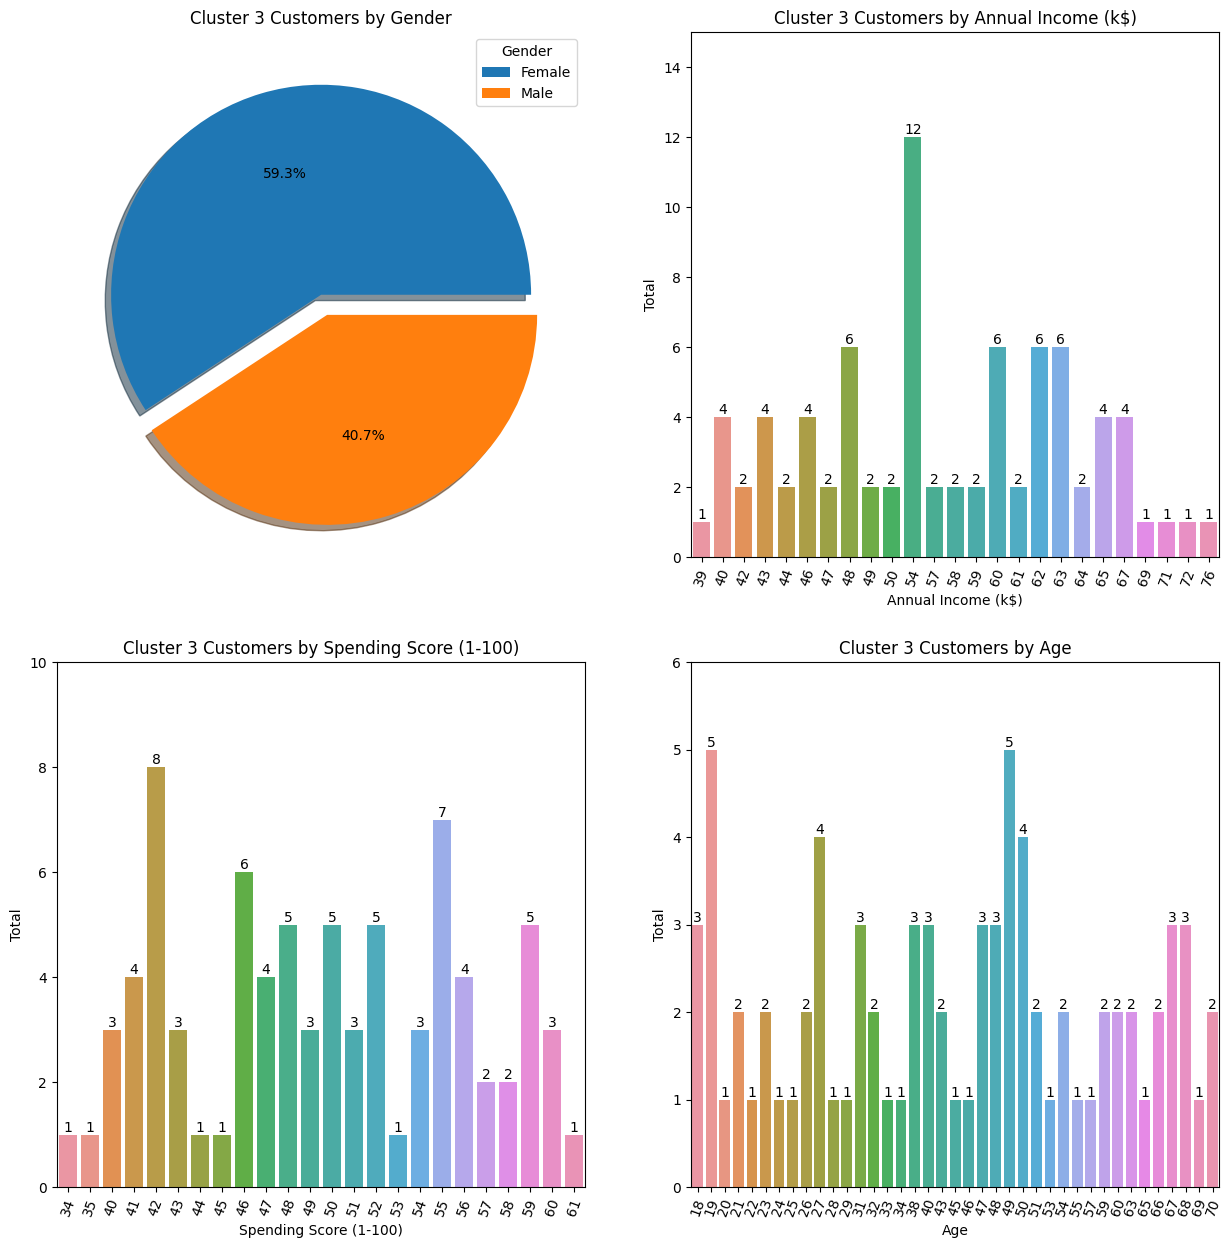

In [42]:
#Based on cluster 3
cluster_3 = dataset.loc[dataset['Cluster'] == 2]
gender_cluster_3 = cluster_3['Gender'].value_counts()

fig = plt.figure(figsize=(15, 15))

#Data Visualization 21
explode = (0, 0.1)
ax1 = fig.add_subplot(2, 2, 1)
ax1.pie(gender_cluster_3, explode=explode, shadow=True, autopct='%1.1f%%')
ax1.set_title("Cluster 3 Customers by Gender")
ax1.legend(gender_cluster_3.keys(), title ="Gender")

#Data Visualization 22
ax2 = fig.add_subplot(2, 2, 2)
vis22 = sns.countplot(x='Annual Income (k$)', data=cluster_3, ax=ax2)
ax2.set_ylabel("Total")
ax2.set_title("Cluster 3 Customers by Annual Income (k$)")
ax2.set_ylim(0, 15)
for item in vis22.get_xticklabels():
    item.set_rotation(70)
for i in vis22.containers:
    vis22.bar_label(i, fmt='%.0f')

#Data Visualization 23
ax2 = fig.add_subplot(2, 2, 3)
vis23 = sns.countplot(x='Spending Score (1-100)', data=cluster_3, ax=ax2)
ax2.set_ylabel("Total")
ax2.set_title("Cluster 3 Customers by Spending Score (1-100)")
ax2.set_ylim(0, 10)
for item in vis23.get_xticklabels():
    item.set_rotation(70)
for i in vis23.containers:
    vis23.bar_label(i, fmt='%.0f')

#Data Visualization 24
ax2 = fig.add_subplot(2, 2, 4)
vis24 = sns.countplot(x='Age', data=cluster_3, ax=ax2)
ax2.set_ylabel("Total")
ax2.set_title("Cluster 3 Customers by Age")
ax2.set_ylim(0, 6)
for item in vis24.get_xticklabels():
    item.set_rotation(70)
for i in vis24.containers:
    vis24.bar_label(i, fmt='%.0f')


The figure above is shows that **cluster 3** which is **moderate income and moderate spending** compared to other cluster. Cluster 3 contains customers with 40.7% are males and 59.3% are females. Also, we can see that most customers are come from age 27 to 49 age old. Targeting the segment of customers with moderate income and moderate spending requires a balanced approach that focuses on providing value, affordability, and a satisfying shopping experience. The mall can utilize targeted email campaigns, SMS marketing, or social media advertising to inform customers about relevant promotions, discounts, or new product launches that align with their interests and budget. Also, offer a wide range of products at different price points, ensuring that customers with varying budgets can find suitable options. Moreover, the mall may collect and address customer feedback promptly to continuously improve the customer experience and identify opportunities to better cater to their needs.

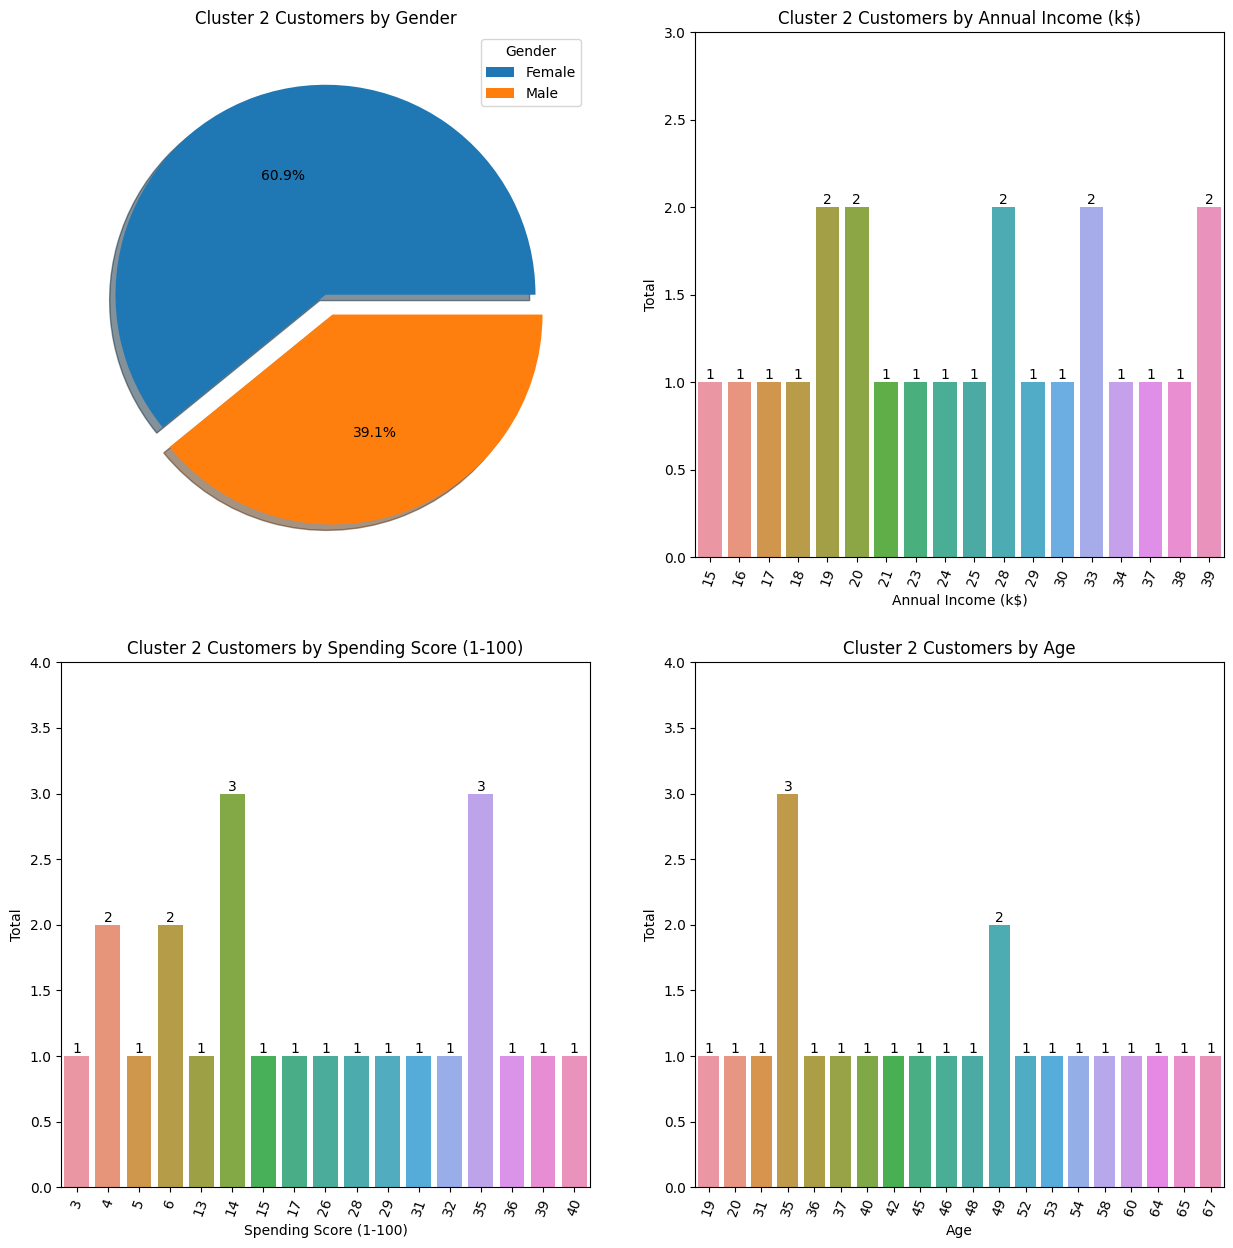

In [44]:
#Based on cluster 2
cluster_2 = dataset.loc[dataset['Cluster'] == 1]
gender_cluster_2 = cluster_2['Gender'].value_counts()

fig = plt.figure(figsize=(15, 15))

#Data Visualization 25
explode = (0, 0.1)
ax1 = fig.add_subplot(2, 2, 1)
ax1.pie(gender_cluster_2, explode=explode, shadow=True, autopct='%1.1f%%')
ax1.set_title("Cluster 2 Customers by Gender")
ax1.legend(gender_cluster_2.keys(), title ="Gender")

#Data Visualization 26
ax2 = fig.add_subplot(2, 2, 2)
vis26 = sns.countplot(x='Annual Income (k$)', data=cluster_2, ax=ax2)
ax2.set_ylabel("Total")
ax2.set_title("Cluster 2 Customers by Annual Income (k$)")
ax2.set_ylim(0, 3)
for item in vis26.get_xticklabels():
    item.set_rotation(70)
for i in vis26.containers:
    vis26.bar_label(i, fmt='%.0f')

#Data Visualization 27
ax2 = fig.add_subplot(2, 2, 3)
vis27 = sns.countplot(x='Spending Score (1-100)', data=cluster_2, ax=ax2)
ax2.set_ylabel("Total")
ax2.set_title("Cluster 2 Customers by Spending Score (1-100)")
ax2.set_ylim(0, 4)
for item in vis27.get_xticklabels():
    item.set_rotation(70)
for i in vis27.containers:
    vis27.bar_label(i, fmt='%.0f')

#Data Visualization 28
ax2 = fig.add_subplot(2, 2, 4)
vis28 = sns.countplot(x='Age', data=cluster_2, ax=ax2)
ax2.set_ylabel("Total")
ax2.set_title("Cluster 2 Customers by Age")
ax2.set_ylim(0, 4)
for item in vis28.get_xticklabels():
    item.set_rotation(70)
for i in vis28.containers:
    vis28.bar_label(i, fmt='%.0f')


The figure above is shows that **cluster 2** which is **less income and less spending** compared to other cluster. Cluster 2 contains customers with 39.1% are males and 60.9% are females. Also, we can see that most customers are come from age 35 to 49 age old. Targeting the segment of customers with lower income and lower spending requires a focus on affordability, value, and meeting their basic needs. The mall can implement price matching policies to assure customers that they are getting the best value for their money. Next, the mall may Leverage community-based platforms or local advertising channels to connect with customers within their immediate vicinity. Also, the mall may create engaging and informative content that provides tips, advice, or cost-saving ideas to demonstrate your understanding of their financial constraints.

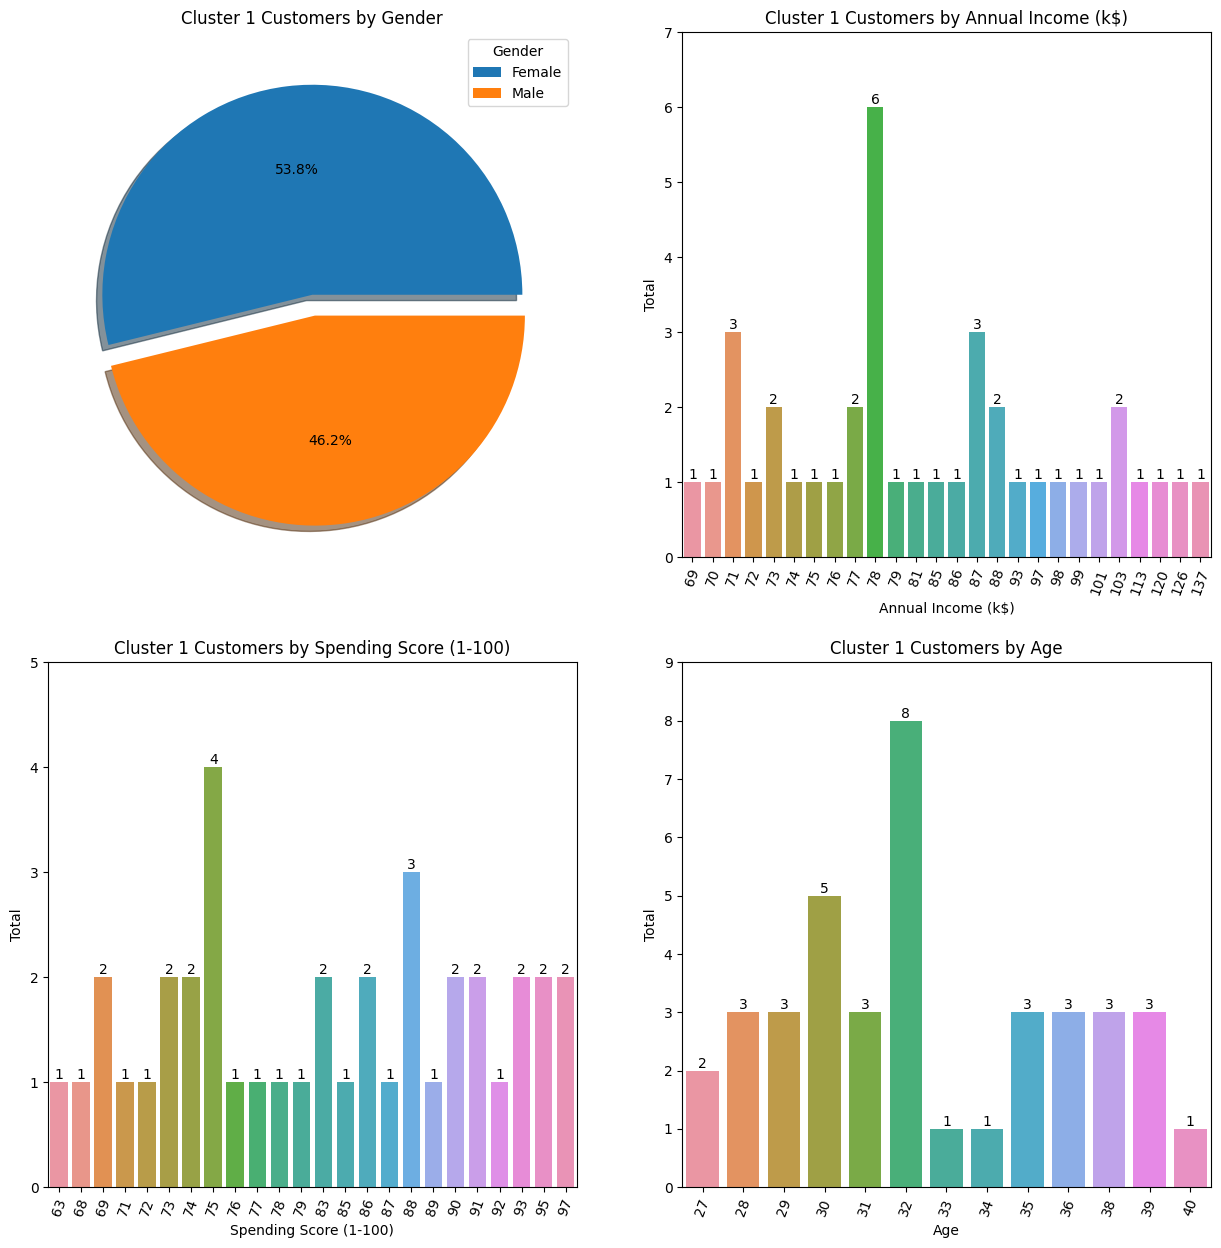

In [47]:
#Based on cluster 1
cluster_1 = dataset.loc[dataset['Cluster'] == 0]
gender_cluster_1 = cluster_1['Gender'].value_counts()

fig = plt.figure(figsize=(15, 15))

#Data Visualization 29
explode = (0, 0.1)
ax1 = fig.add_subplot(2, 2, 1)
ax1.pie(gender_cluster_1, explode=explode, shadow=True, autopct='%1.1f%%')
ax1.set_title("Cluster 1 Customers by Gender")
ax1.legend(gender_cluster_1.keys(), title ="Gender")

#Data Visualization 30
ax2 = fig.add_subplot(2, 2, 2)
vis30 = sns.countplot(x='Annual Income (k$)', data=cluster_1, ax=ax2)
ax2.set_ylabel("Total")
ax2.set_title("Cluster 1 Customers by Annual Income (k$)")
ax2.set_ylim(0, 7)
for item in vis30.get_xticklabels():
    item.set_rotation(70)
for i in vis30.containers:
    vis30.bar_label(i, fmt='%.0f')

#Data Visualization 31
ax2 = fig.add_subplot(2, 2, 3)
vis31 = sns.countplot(x='Spending Score (1-100)', data=cluster_1, ax=ax2)
ax2.set_ylabel("Total")
ax2.set_title("Cluster 1 Customers by Spending Score (1-100)")
ax2.set_ylim(0, 5)
for item in vis31.get_xticklabels():
    item.set_rotation(70)
for i in vis31.containers:
    vis31.bar_label(i, fmt='%.0f')

#Data Visualization 32
ax2 = fig.add_subplot(2, 2, 4)
vis32 = sns.countplot(x='Age', data=cluster_1, ax=ax2)
ax2.set_ylabel("Total")
ax2.set_title("Cluster 1 Customers by Age")
ax2.set_ylim(0, 9)
for item in vis32.get_xticklabels():
    item.set_rotation(70)
for i in vis32.containers:
    vis32.bar_label(i, fmt='%.0f')


The figure above is shows that **cluster 1** which is **high income and high spending** compared to other cluster which also our targeted customers. Cluster 1 contains customers with 46.2% are males and 53.8% are females. Also, we can see that most customers are come from age 28 to 39 age old. Targeting the segment of customers with high income and high spending requires a focus on luxury, exclusivity, and personalized experiences. The mall can partner with luxury brands or designers to offer exclusive collections, co-branded products, or collaborations that appeal to this segment's refined tastes. Moreover, provide a personalized and highly attentive customer service experience to cater to the discerning needs of high-income customers. Not only that, the mall can offer members-only perks, such as early access to new collections, priority booking for services, or complimentary upgrades to enhance the sense of exclusivity and reward their loyalty. Also, leverage technology like augmented reality or virtual reality to offer virtual try-on or visualization of customized products.

As a conclusion, **high income and high spending** are the most beneficial ones to the mall owners which increases the owner’s business.

### Advantages of K-Means Clustering 

K-means clustering is advantageous for customer segmentation due to its simplicity, scalability, interpretability, and fast convergence. K-means clustering can handle large datasets efficiently, making it suitable for analyzing and segmenting large customer databases. It can process data points in parallel, allowing for faster computations. K-means clustering can handle both continuous and categorical variables, allowing for a comprehensive analysis of customer attributes, such as demographics, purchase behavior, or preferences. Moreover,  K-means clustering provides clear boundaries between clusters, making it easier to interpret the results. Each data point is assigned to a single cluster, allowing for straightforward characterization and understanding of the different segments. Once the customer segments are identified through K-means clustering, it becomes easier to develop targeted marketing strategies for each segment. By understanding the distinct characteristics and preferences of each segment, businesses can tailor their marketing efforts, product offerings, pricing strategies, and promotional activities to better cater to the needs and preferences of each segment.

### Limitations of K-Means Clustering 

K-means clustering has several limitations that are important to consider when using it for customer segmentation. Firstly, K-means clustering is sensitive to the initial placement of centroids. Different initial configurations can lead to different final cluster assignments and results. It is recommended to run the algorithm multiple times with different initializations and choose the best result based on a defined criterion. Secondly, selecting the appropriate number of clusters (k) is a subjective task in K-means clustering. There is no definitive method to determine the optimal number of clusters, and it often requires trial and error or domain knowledge. Choosing an incorrect number of clusters can lead to suboptimal results and misinterpretation of the customer segments. Next, K-means clustering is sensitive to the scale of the features. Features with larger magnitudes can dominate the clustering process, leading to biased results. It is important to normalize or standardize the features before applying K-means clustering to ensure that all features contribute equally to the clustering process. Also, K-means clustering does not provide a hierarchical structure of clusters. It assigns each data point to a single cluster, without considering potential subclusters or overlapping clusters. If a hierarchical representation of the data is desired, hierarchical clustering techniques may be more appropriate.